In [1]:
from pyprojroot import here
print("Project root:", here())

Project root: C:\Users\hanis\Flight\flight-delay-prediction


# Relationship EDA

### The phase of data analysis where you look at how two or more variables interact with each other.
Let's start by seeing all the columns present

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_parquet(here("data/processed/clean.parquet"))
print(df.columns)
df.head()

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       'Flight_Number_Reporting_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest',
       'DestCityName', 'DestState', 'DestStateFips', 'DestStateName',
       'DestWac', 'CRSDepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'CRSArrTime',
       'ArrivalDelayGroups', 'ArrTimeBlk', 'Flights', 'Distance',
       'DistanceGroup'],
      dtype='object')


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,CRSArrTime,ArrivalDelayGroups,ArrTimeBlk,Flights,Distance,DistanceGroup
0,2024,4,10,29,2,2024-10-29,UA,19977,UA,N37504,...,0.0,0.0,-1.0,1300-1359,1532,-2.0,1500-1559,1.0,2133.0,9
1,2024,4,10,29,2,2024-10-29,UA,19977,UA,N69824,...,0.0,0.0,-1.0,1900-1959,2056,-2.0,2000-2059,1.0,455.0,2
2,2024,4,10,29,2,2024-10-29,UA,19977,UA,N37297,...,0.0,0.0,-1.0,0900-0959,1218,-2.0,1200-1259,1.0,1041.0,5
3,2024,4,10,29,2,2024-10-29,UA,19977,UA,N47569,...,0.0,0.0,-1.0,1300-1359,1505,-2.0,1500-1559,1.0,888.0,4
4,2024,4,10,29,2,2024-10-29,UA,19977,UA,N69826,...,0.0,0.0,-1.0,1200-1259,1538,-1.0,1500-1559,1.0,1846.0,8


# 1. Departure Hour vs DepDel15


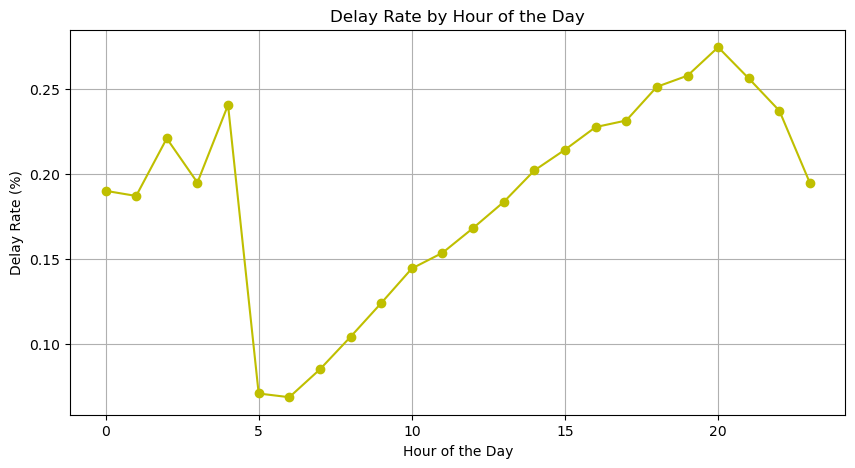

    dep_hour  total_flights  delay_rate
0          0           4936    0.190032
1          1           1401    0.187009
2          2            489    0.220859
3          3            390    0.194872
4          4            158    0.240506
5          5          81328    0.070775
6          6         202132    0.068584
7          7         208164    0.084995
8          8         205677    0.104129
9          9         168180    0.123956
10        10         182107    0.144322
11        11         192100    0.153524
12        12         175724    0.168110
13        13         177197    0.183474
14        14         174163    0.202006
15        15         168758    0.214212
16        16         171971    0.227533
17        17         185343    0.231398
18        18         180078    0.251241
19        19         156743    0.257779
20        20         130963    0.274513
21        21          89754    0.256133
22        22          66511    0.237104
23        23          23577    0.194427


In [14]:
df["dep_hour"] = df["CRSDepTime"] // 100

hour_wise_delay = (
    df.groupby("dep_hour")
    .agg(
        total_flights = ("DepDel15", "count"),
        delay_rate = ("DepDel15", "mean")
    )
    .reset_index()
)
airline_delay["delay_rate"] *= 100

plt.figure(figsize=(10,5))

plt.plot(
    hour_wise_delay["dep_hour"],
    hour_wise_delay["delay_rate"],
    marker="o",
    color = "y"
)

plt.xlabel("Hour of the Day")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Hour of the Day")

plt.grid(True)
plt.show()

print(hour_wise_delay)

# 2. Airline vs DepDel15


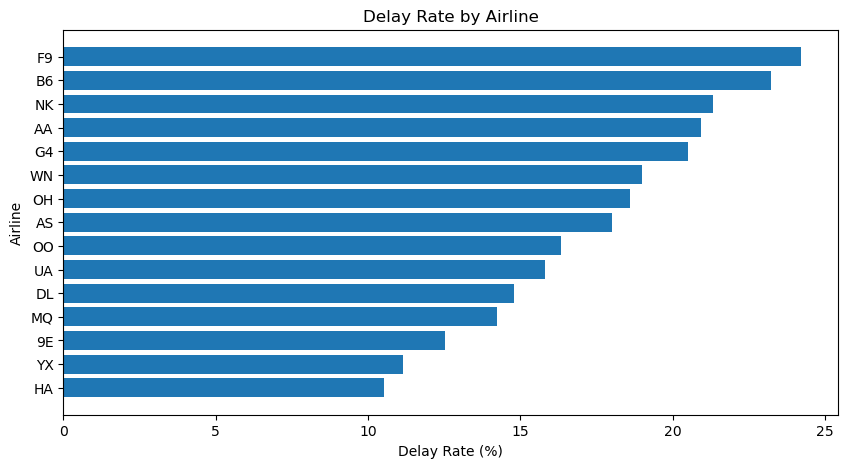

   Reporting_Airline  total_flights  delay_rate
13                WN         573997   18.992085
4                 DL         425671   14.790766
1                 AA         401987   20.920328
11                OO         327565   16.343321
12                UA         322702   15.801885
14                YX         130711   11.136018
8                 MQ         116406   14.223494
2                 AS         103731   18.005225
9                 NK         102448   21.310323
10                OH         100761   18.602435
3                 B6          96439   23.207416
5                 F9          87129   24.223852
0                 9E          81686   12.510100
6                 G4          43925   20.500854
7                 HA          32686   10.521324


In [17]:
airline_delay = (
    df.groupby("Reporting_Airline")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

airline_delay["delay_rate"] *= 100

airline_delay.sort_values(
    "delay_rate",
    ascending=True,
    inplace=True
)

airline_delay.head()

plt.figure(figsize=(10,5))

plt.barh(
    airline_delay["Reporting_Airline"],
    airline_delay["delay_rate"]
)


plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")
plt.title("Delay Rate by Airline")

airline_delay.sort_values(
    "total_flights",
    ascending=False,
    inplace=True
)
plt.show()

print(airline_delay)

# 3. Day of week vs DepDel15


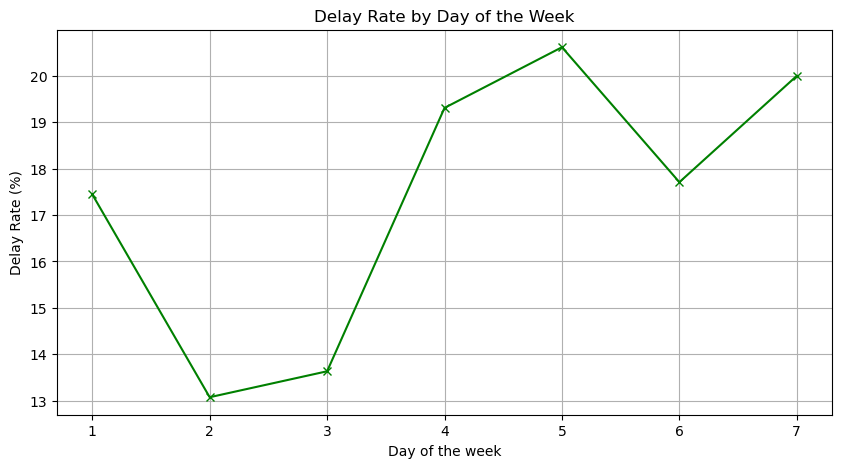

   DayOfWeek  total_flights  delay_rate
0          1         449699   17.445669
1          2         395878   13.076503
2          3         384271   13.635169
3          4         437337   19.307079
4          5         447521   20.613558
5          6         384074   17.707785
6          7         449064   19.997372


In [13]:
dayOfWeek_delay = (
    df.groupby("DayOfWeek")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

dayOfWeek_delay["delay_rate"] *= 100

dayOfWeek_delay.head()

plt.figure(figsize=(10,5))

plt.plot(
    dayOfWeek_delay["DayOfWeek"],
    dayOfWeek_delay["delay_rate"],
    marker="x",
    color = 'g'
)

plt.xlabel("Day of the week")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Day of the Week")

plt.grid(True)
plt.show()

print(dayOfWeek_delay)


# 4. Airport vs DepDel15

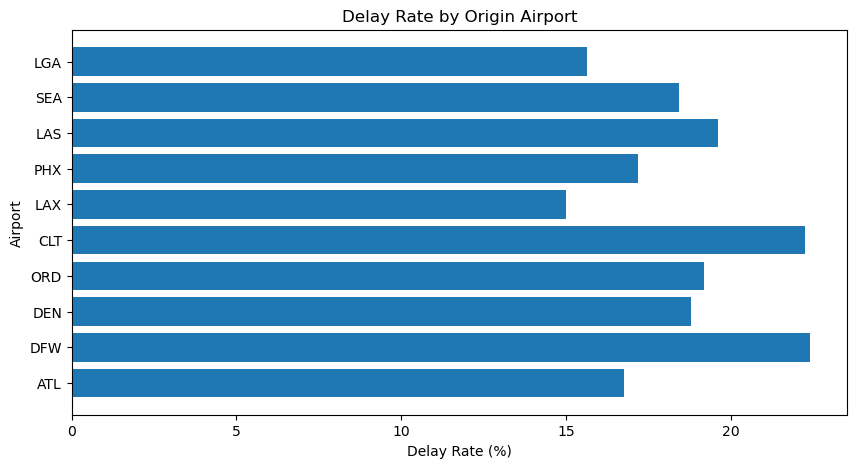

    Origin  total_flights  delay_rate
20     ATL         143393   16.750469
90     DFW         131260   22.405150
89     DEN         130421   18.784552
238    ORD         119683   19.184011
69     CLT          91522   22.263499
183    LAX          81769   14.991011
249    PHX          81181   17.175201
181    LAS          79689   19.611239
294    SEA          69130   18.442066
192    LGA          66766   15.650181


In [22]:
airport_delay = (
    df.groupby("Origin")
    .agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    )
    .reset_index()
)

airport_delay["delay_rate"] *= 100

top10_airports = airport_delay.sort_values(
    by="total_flights",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10_airports["Origin"],
    top10_airports["delay_rate"]
)


plt.xlabel("Delay Rate (%)")
plt.ylabel("Airport")
plt.title("Delay Rate by Origin Airport")

plt.show()

print(top10_airports)

# 5. Distance vs DepDel15

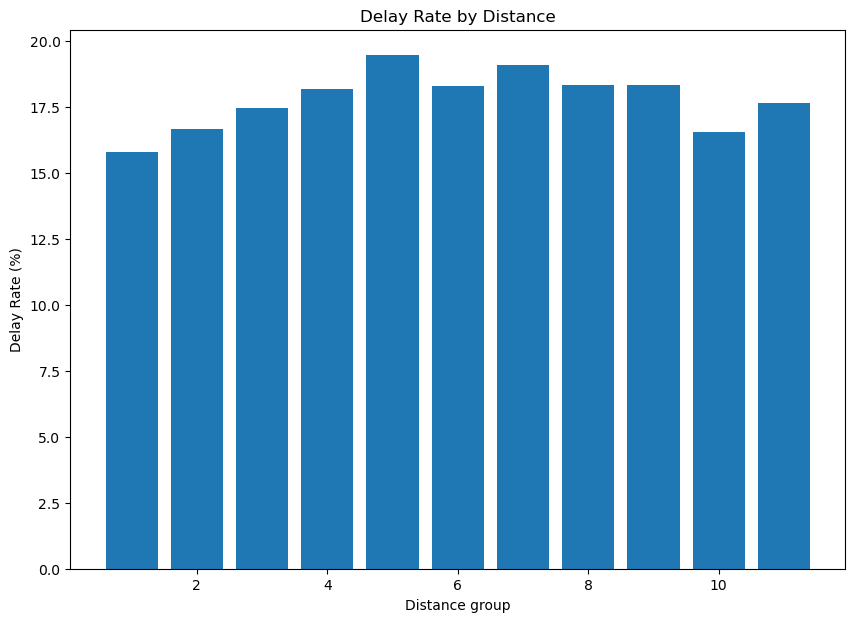

    DistanceGroup  total_flights  delay_rate
0               1         338972   15.782720
1               2         692552   16.657811
2               3         597737   17.451655
3               4         474508   18.169767
4               5         326242   19.461320
5               6         136537   18.294675
6               7         133113   19.108577
7               8          67424   18.319886
8               9          48832   18.324050
9              10          72351   16.566461
10             11          59576   17.671546


In [26]:
dist_delay = (
    df.groupby("DistanceGroup").agg(
        total_flights=("DepDel15", "count"),
        delay_rate=("DepDel15", "mean")
    ).reset_index()
)

dist_delay["delay_rate"] *= 100

plt.figure(figsize=(10,7))

plt.bar(
    dist_delay["DistanceGroup"],
    dist_delay["delay_rate"]
)


plt.xlabel("Distance group")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Distance")

plt.show()

print(dist_delay)

# 6. Correlation Analysis(Heatmap)

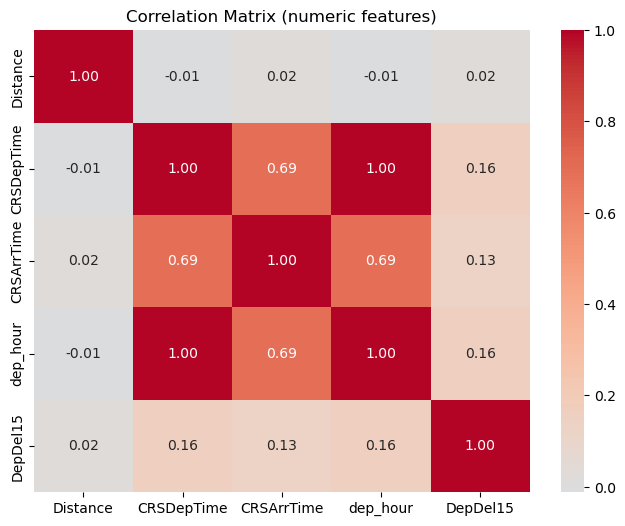

In [27]:
num_cols = ["Distance", "CRSDepTime", "CRSArrTime", "dep_hour", "DepDel15"]

corr = df[num_cols].corr()   # Pearson by default

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (numeric features)")
plt.show()